In [43]:
import pandas as pd
data = pd.read_csv('教育現況評論.csv', encoding='utf-8')
data.head()

,Id,Comment
0,Et Et,私校教師分幾種第一，皇親國戚工作最輕鬆錢最多權力地位最大無法無天第二，有皇親國戚做靠山的老師...
1,Kelly,不能用公私立二分法，公立有明星學區跟彈簧刀學區。私立也有繳錢私立跟升學私立。最恐怖的彈簧刀公...
2,Nell Chang,教育本質還是家庭教育，家長應該要在家庭教育上多用心，而不是覺得把孩子送進私校就可以把「教育」...
3,黃鳳純,教育部是否該重視這個問題…為什麼大家要擠破頭要去讀私校！
4,George Chung,很明顯就是齊頭式教育啊…


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Id       120 non-null    object
 1   Comment  120 non-null    object
dtypes: object(2)
memory usage: 2.0+ KB


In [45]:
import re #
import jieba # 目前python最好的中文分詞
from collections import Counter

In [46]:
def clean_text(text):
    return re.sub(r"[^\u4e00-\u9fa5]", "", text)
data['clean_comment'] = data['Comment'].apply(clean_text)
data.head()

,Id,Comment,clean_comment
0,Et Et,私校教師分幾種第一，皇親國戚工作最輕鬆錢最多權力地位最大無法無天第二，有皇親國戚做靠山的老師...,私校教師分幾種第一皇親國戚工作最輕鬆錢最多權力地位最大無法無天第二有皇親國戚做靠山的老師皇親...
1,Kelly,不能用公私立二分法，公立有明星學區跟彈簧刀學區。私立也有繳錢私立跟升學私立。最恐怖的彈簧刀公...,不能用公私立二分法公立有明星學區跟彈簧刀學區私立也有繳錢私立跟升學私立最恐怖的彈簧刀公立學校...
2,Nell Chang,教育本質還是家庭教育，家長應該要在家庭教育上多用心，而不是覺得把孩子送進私校就可以把「教育」...,教育本質還是家庭教育家長應該要在家庭教育上多用心而不是覺得把孩子送進私校就可以把教育這件事丟...
3,黃鳳純,教育部是否該重視這個問題…為什麼大家要擠破頭要去讀私校！,教育部是否該重視這個問題為什麼大家要擠破頭要去讀私校
4,George Chung,很明顯就是齊頭式教育啊…,很明顯就是齊頭式教育啊


In [47]:
data['tokens'] = data['clean_comment'].apply(lambda x: jieba.lcut(x))

with open("停用詞-繁體中文.txt", encoding="utf-8") as f:
    stopwords = set(f.read().splitlines())

data["tokens"] = data["tokens"].apply(lambda words: [w for w in words if w not in stopwords])

data.head()

,Id,Comment,clean_comment,tokens
0,Et Et,私校教師分幾種第一，皇親國戚工作最輕鬆錢最多權力地位最大無法無天第二，有皇親國戚做靠山的老師...,私校教師分幾種第一皇親國戚工作最輕鬆錢最多權力地位最大無法無天第二有皇親國戚做靠山的老師皇親...,"[私校, 教師分, 幾種, 第一, 皇親, 國戚, 工作, 最, 輕, 鬆, 錢, 最, 權..."
1,Kelly,不能用公私立二分法，公立有明星學區跟彈簧刀學區。私立也有繳錢私立跟升學私立。最恐怖的彈簧刀公...,不能用公私立二分法公立有明星學區跟彈簧刀學區私立也有繳錢私立跟升學私立最恐怖的彈簧刀公立學校...,"[公私, 二分法, 公立, 明星, 學區, 彈簧刀, 學區, 私立, 繳錢, 私立, 升學,..."
2,Nell Chang,教育本質還是家庭教育，家長應該要在家庭教育上多用心，而不是覺得把孩子送進私校就可以把「教育」...,教育本質還是家庭教育家長應該要在家庭教育上多用心而不是覺得把孩子送進私校就可以把教育這件事丟...,"[教育, 本質, 家庭教育, 家長, 應該, 家庭教育, 用心, 覺得, 孩子, 送進, 私..."
3,黃鳳純,教育部是否該重視這個問題…為什麼大家要擠破頭要去讀私校！,教育部是否該重視這個問題為什麼大家要擠破頭要去讀私校,"[教育部, 是否, 重視, 問題, 擠, 破頭, 讀, 私校]"
4,George Chung,很明顯就是齊頭式教育啊…,很明顯就是齊頭式教育啊,"[很明顯, 齊頭式, 教育]"


In [48]:
all_words = sum(data['tokens'].tolist(), [])

words_counts = Counter(all_words)
print(words_counts.most_common(20))

[('私校', 53), ('學校', 47), ('老師', 42), ('公立', 32), ('孩子', 28), ('問題', 24), ('私立', 22), ('教育', 22), ('學生', 20), ('錢', 19), ('家長', 19), ('小孩', 19), ('好', 16), ('教育部', 14), ('真的', 14), ('後', 13), ('公校', 13), ('一堆', 12), ('人', 12), ('不用', 11)]


In [49]:
sum(words_counts.values())

2003

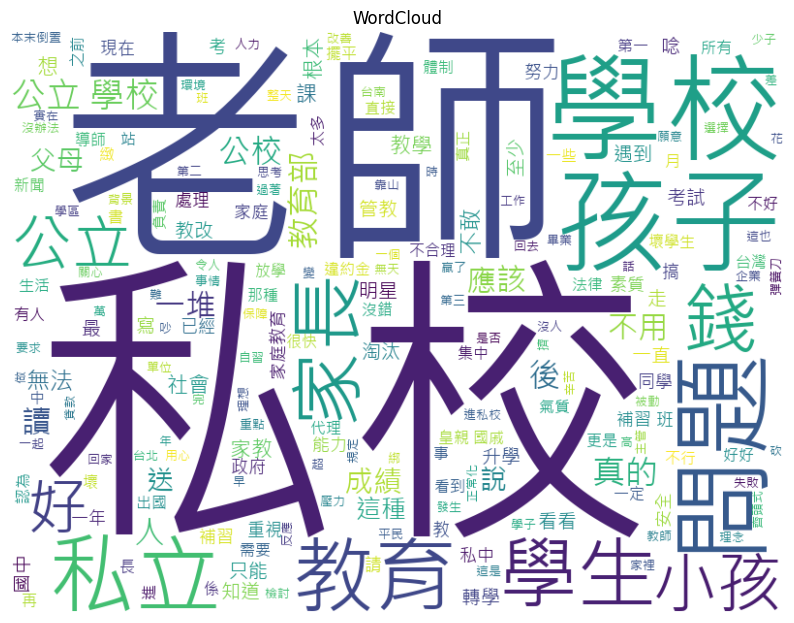

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

words_string = ' '.join(all_words)

wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/msjh.ttc',
    background_color='white',
    width=800,
    height=600,
    random_state=42
).generate(words_string)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud')
plt.show()

In [52]:
from umap import UMAP

In [2]:
import xgboost